# 将广西大学东盟Agent助手接入该项目, 测准确率相比原rag提升了多少
# 问题: 用了哪些数据库; 只能保存pdf吗; 涉及哪些设计模式

# 配置层要的是“轻量结构 + 最小校验”，不是完整校验框架，所以选标准库 dataclass而不是Pydantic
@dataclass 是 Python 标准库（dataclasses）提供的装饰器，用来少写样板代码、快速定义“主要用来存数据”的类

@dataclass(frozen=True)
class LLMSettings:
    provider: str

不加装饰器时，你通常要手写 __init__、__repr__、__eq__ 等。加上 @dataclass 后，它根据类属性自动生成这些方法。
一句话：dataclass = 用类属性描述数据结构，由解释器帮你生成初始化、打印、比较等样板代码。
frozen=True 表示配置加载后是只读快照，避免别处误改 settings.llm.model。

# 用于存储原始文件；提供几个方法负责校验和 dict 互转。
@dataclass
class Document:
    # 原始文件存储格式
    # Example:
    #     >>> doc = Document(
    #     ...     id="doc_abc123",
    #     ...     text="# Title\\n\\nContent...",
    #     ...     metadata={
    #     ...         "source_path": "data/documents/report.pdf",
    #     ...         "doc_type": "pdf",
    #     ...         "title": "Annual Report 2025"
    #     ...     }
    #     ... )

    id: str
    text: str
    metadata: Dict[str, Any] = field(default_factory=dict)
    
    # dataclass 构造完后自动跑；检查 metadata 里有没有 source_path
    def __post_init__(self):
        """Validate required metadata fields."""
        if "source_path" not in self.metadata:
            raise ValueError("Document metadata must contain 'source_path'")
    
    # 对象 → dict（方便 JSON/落盘）
    def to_dict(self) -> Dict[str, Any]:
        """Convert to dictionary for serialization."""
        return asdict(self) # 读 self 上的 dataclass 字段，拼成字典
        # asdict 来自标准库 dataclasses
        # 它只对@dataclass类有效：这类对象的字段是声明好的（id、text、metadata），asdict 会按这些字段递归拷贝成普通 dict。
    
    # dict → Document 对象（和 Settings 的 from_dict 同类工厂方法）
    @classmethod
    def from_dict(cls, data: Dict[str, Any]) -> "Document":
        """Create Document from dictionary."""
        return cls(**data)

self是实例
cls是类

cls(**data)
**data 是 Python 的字典拆包（unpack），把 dict 拆成关键字参数传给函数/构造器

假设
data = {
    "id": "doc_1",
    "text": "hello",
    "metadata": {"source_path": "a.pdf"}
}

cls(**data)

相当于
cls(
    id="doc_1",
    text="hello",
    metadata={"source_path": "a.pdf"}
)
** 把 data 里的每个 键: 值 变成 键=值 传进去。

写法	作用	例子
* args / * list   按位置拆序列    f(*[1,2]) → f(1, 2)
** kwargs / ** dict   按关键字拆字典  f(**{"a":1}) → f(a=1)

type[BaseLLM] 是 Python 类型注解（Type Hint）中的一种写法，用于表示 "BaseLLM 这个类本身"​ 的类型，而不是 BaseLLM 的实例。

写法	含义
BaseLLM	    BaseLLM 的实例​
type[BaseLLM]	BaseLLM 这个类本身（或者说 BaseLLM 的子类）
简单说，type[X] 表示 "X 类或其子类的类对象"。

BM25（Best Matching 25）是传统自然语言处理和信息检索领域最经典、最成功的关键词匹配算法。比如 Elasticsearch (ES) 的默认打分机制就是 BM25。
它的核心思想是：评估用户查询的关键词（Query）与候选文档（Document）之间的相关性得分。 得分越高，文档越匹配。

BM25 的算分逻辑建立在三个核心支柱之上，这正好呼应了你前面代码中提取的统计特征：

1. 词频 (Term Frequency, TF) —— “提的越多越相关，但有上限”
概念： 搜索词在文档中出现的次数。
BM25 的优化： 传统的 TF 是线性的（出现 10 次的权重是出现 1 次的 10 倍），这显然不合理。BM25 引入了“词频饱和”概念。当词频增加到一定程度时，得分的增长会逐渐趋缓并达到上限。
代码对应： term_frequencies

2. 逆文档频率 (Inverse Document Frequency, IDF) —— “物以稀为贵”
概念： 这个词在整个语料库中有多常见。

逻辑： 如果用户搜“苹果 手机”，其中“手机”在所有文章中都很常见（IDF 低），而“苹果”只在特定文章中出现（IDF 高），那么“苹果”这个词对搜索得分的贡献度就会远大于“手机”。如果是一个极罕见的专有名词（如“BM25算法”），它的权重会极高。

代码对应： document_frequency 和 num_docs

3. 文档长度惩罚 (Document Length Normalization) —— “长文天然占优，需要打压”
概念： 较长的文档包含了更多的词，因此纯靠运气命中关键词的概率也更高。

逻辑： 如果一篇 100 字的短文命中了一次“人工智能”，和一篇 10000 字的长文命中了一次“人工智能”，显然是 100 字的短文与“人工智能”的主题更高度相关。BM25 会对比当前文档长度与整个语料库的平均文档长度，对超长的文档进行分数惩罚。

代码对应： doc_length 和 avg_doc_length

稀疏vs稠密
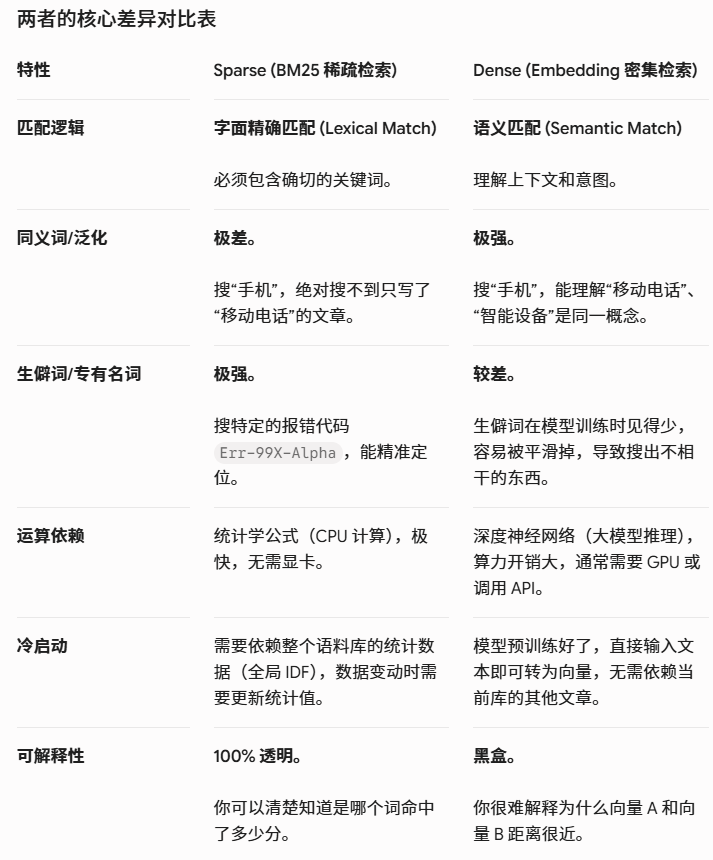
检索路	存什么	存在哪
稠密（语义）    embedding向量  Chroma（VectorUpserter）
稀疏（关键词）  BM25倒排索引  JSON 文件（本文件）

BM25无需大模型encoding
对于经典的 BM25 算法来说，并没有一个所谓的“预训练神经网络大模型”可以导入。它的“模型”其实就是两样东西的组合：
分词器 (Tokenizer)： 比如中文的 jieba、英文的 nltk 或 tiktoken。
词频统计逻辑： 也就是计算 TF（词频）和 IDF（逆文档频率）的数学公式。

具体做法:
怎么做？
    当你有一句话“苹果手机怎么重启”，你会：
    用 jieba 把它切成 ["苹果", "手机", "怎么", "重启"]。
    统计这个文档里每个词出现了几次（TF）。
    统计这些词在你整个知识库里出现了几次（用来算 IDF）。
    产出物是什么？
    它产出的不是一串毫无意义的浮点数，而是一个 字典 (Dictionary)：
    {"苹果": 1.2, "手机": 0.8, "重启": 2.5} （键是词，值是 BM25 算出来的权重）。
    注：这也是为什么很多老牌搜索引擎（如 Elasticsearch）天然自带 BM25，因为它们底层就是做倒排索引和词频统计的

# PDF文件处理
将pdf转为md文件格式
原odf中图片的位置用占位符表示
占位符保存图片id, 可以去metedata中找到图片的存储地址

# 项目数据库设置
SQLite 用于存储文档处理状态, 包括SHA256指纹、SHA256指纹等
Chroma / pgvector用于存储向量


# WAL模式
Write-Ahead Logging（预写日志）
它是 SQLite 的一种事务日志机制。
允许读写并发
